In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import kagglehub

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

c:\Users\madha\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Download dataset
path = kagglehub.dataset_download("vikrishnan/boston-house-prices")

print("Dataset Path:", path)

100%|██████████| 12.8k/12.8k [00:00<00:00, 6.57MB/s]

Extracting files...
Dataset Path: C:\Users\madha\.cache\kagglehub\datasets\vikrishnan\boston-house-prices\versions\1


In [7]:
import os

file_path = os.path.join(path, "housing.csv")
df = pd.read_csv(file_path, sep="\s+", header=None)
df.columns = [
'CRIM','ZN','INDUS','CHAS','NOX','RM','AGE',
'DIS','RAD','TAX','PTRATIO','B','LSTAT','MEDV'
]

df.head()

<>:4: SyntaxWarning: invalid escape sequence '\s'
<>:4: SyntaxWarning: invalid escape sequence '\s'
C:\Users\madha\AppData\Local\Temp\ipykernel_8852\928981956.py:4: SyntaxWarning: invalid escape sequence '\s'
  df = pd.read_csv(file_path, sep="\s+", header=None)


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2


In [8]:
df.shape
df.columns
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     506 non-null    float64
 1   ZN       506 non-null    float64
 2   INDUS    506 non-null    float64
 3   CHAS     506 non-null    int64  
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      506 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    int64  
 9   TAX      506 non-null    float64
 10  PTRATIO  506 non-null    float64
 11  B        506 non-null    float64
 12  LSTAT    506 non-null    float64
 13  MEDV     506 non-null    float64
dtypes: float64(12), int64(2)
memory usage: 55.5 KB


CRIM       0
ZN         0
INDUS      0
CHAS       0
NOX        0
RM         0
AGE        0
DIS        0
RAD        0
TAX        0
PTRATIO    0
B          0
LSTAT      0
MEDV       0
dtype: int64

In [18]:
X = df.drop('MEDV', axis=1).values
y = df['MEDV'].values

In [19]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [21]:
from sklearn.model_selection import train_test_split

# Train + temp
X_train, X_temp, y_train, y_temp = train_test_split(
    X_scaled, y, test_size=0.3, random_state=42)

# Validation + Test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42)

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Train: (354, 13)
Validation: (76, 13)
Test: (76, 13)


In [25]:
import numpy as np
def gaussian_kernel(x, xi, tau):
    diff = x - xi
    return np.exp(-(np.dot(diff, diff)) / (2 * tau**2))

In [29]:
def locally_weighted_regression(X_train, y_train, X_query, tau=0.5):

    m = X_train.shape[0]
    X_train_aug = np.hstack((np.ones((m,1)), X_train))

    predictions = []

    for x in X_query:

        weights = np.array([
            gaussian_kernel(x, xi, tau) for xi in X_train
        ])

        W = np.diag(weights.flatten())

        theta = np.linalg.pinv(
            X_train_aug.T @ W @ X_train_aug
        ) @ X_train_aug.T @ W @ y_train

        x_aug = np.concatenate(([1], x))

        y_pred = x_aug @ theta
        predictions.append(y_pred)

    return np.array(predictions)

In [30]:
tau = 0.5

y_val_pred = locally_weighted_regression(
    X_train, y_train, X_val, tau
)

In [31]:
from sklearn.metrics import mean_squared_error, r2_score

mse = mean_squared_error(y_val, y_val_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_val, y_val_pred)

print("Validation MSE:", mse)
print("Validation RMSE:", rmse)
print("Validation R2 Score:", r2)

Validation MSE: 26.71510977103289
Validation RMSE: 5.168666150084845
Validation R2 Score: 0.6148894271455125


In [32]:
y_test_pred = locally_weighted_regression(
    X_train, y_train, X_test, tau
)

mse_test = mean_squared_error(y_test, y_test_pred)
r2_test = r2_score(y_test, y_test_pred)

print("Test MSE:", mse_test)
print("Test R2:", r2_test)

Test MSE: 192.20805257686303
Test R2: -1.4183391211240588


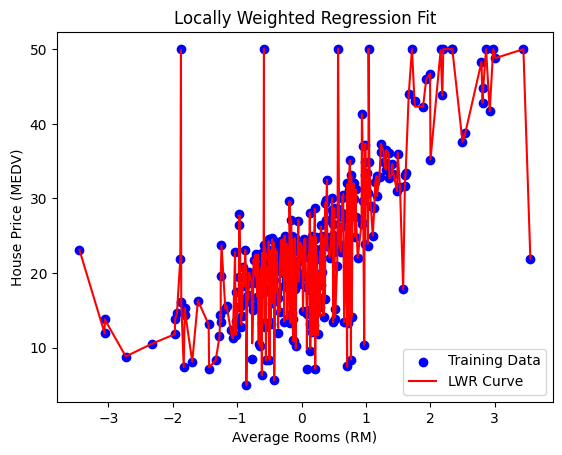

In [34]:
import matplotlib.pyplot as plt

# Plot only RM feature
plt.scatter(X_train[:,5], y_train, color="blue", label="Training Data")

# Sort RM values
sorted_idx = np.argsort(X_train[:,5])
X_sorted = X_train[sorted_idx]

# Predict values
y_pred_plot = locally_weighted_regression(
    X_train, y_train, X_sorted, tau
)

# Plot regression curve
plt.plot(X_sorted[:,5], y_pred_plot, color="red", label="LWR Curve")

plt.xlabel("Average Rooms (RM)")
plt.ylabel("House Price (MEDV)")
plt.title("Locally Weighted Regression Fit")
plt.legend()

plt.show()